Using device: cpu
TASK 3: Custom CNN Model Implementation

1. Preparing Data...
Dataset classes: ['type_1', 'type_10', 'type_11', 'type_12', 'type_13', 'type_14', 'type_15', 'type_16', 'type_2', 'type_3', 'type_4', 'type_5', 'type_6', 'type_7', 'type_8', 'type_9']
Total samples: 3494
Training samples: 2795
Validation samples: 349
Test samples: 350

2. Initializing Custom CNN Model...
Total parameters: 530,192
Trainable parameters: 530,192

3. Starting Training...
Starting training...

Epoch 1/5
--------------------------------------------------


Training: 100%|██████████| 88/88 [01:37<00:00,  1.11s/it, Loss=1.5717, Acc=40.89%]


Train Loss: 1.7770, Train Acc: 40.89%
Val Loss: 2.0950, Val Acc: 36.39%
New best model saved! Validation Accuracy: 36.39%

Epoch 2/5
--------------------------------------------------


Training: 100%|██████████| 88/88 [01:35<00:00,  1.08s/it, Loss=0.7276, Acc=58.57%]


Train Loss: 1.1928, Train Acc: 58.57%
Val Loss: 1.1110, Val Acc: 61.89%
New best model saved! Validation Accuracy: 61.89%

Epoch 3/5
--------------------------------------------------


...

Train Loss: 0.7539, Train Acc: 75.10%
Val Loss: 1.7273, Val Acc: 50.14%
Early stopping counter: 2/3

Epoch 5/5
--------------------------------------------------


Training: 100%|██████████| 88/88 [01:37<00:00,  1.10s/it, Loss=0.6908, Acc=76.46%]


Train Loss: 0.6882, Train Acc: 76.46%
Val Loss: 0.6278, Val Acc: 78.51%
New best model saved! Validation Accuracy: 78.51%

Training completed in 513.17 seconds
Best Validation Accuracy: 78.51%

4. Loading Best Model and Evaluating...


Testing: 100%|██████████| 11/11 [00:06<00:00,  1.64it/s]



Test Accuracy: 83.43%
Inference Time: 6.73 seconds

5. Generating Evaluation Reports...

Detailed Class-wise Metrics:
      Class  Precision    Recall  F1-Score  Support
0    type_1   1.000000  1.000000  1.000000       25
1   type_10   0.931034  1.000000  0.964286       27
2   type_11   0.928571  0.975000  0.951220       40
3   type_12   0.500000  0.833333  0.625000        6
4   type_13   0.857143  0.750000  0.800000        8
5   type_14   0.916667  0.846154  0.880000       13
6   type_15   1.000000  1.000000  1.000000        6
7   type_16   0.846154  0.392857  0.536585       28
8    type_2   0.812500  0.764706  0.787879       17
9    type_3   0.952381  0.869565  0.909091       23
10   type_4   0.666667  1.000000  0.800000       28
11   type_5   1.000000  0.500000  0.666667       14
12   type_6   0.906250  0.852941  0.878788       34
13   type_7   0.880000  0.758621  0.814815       29
14   type_8   0.516129  0.640000  0.571429       25
15   type_9   0.843750  1.000000  0.915254       

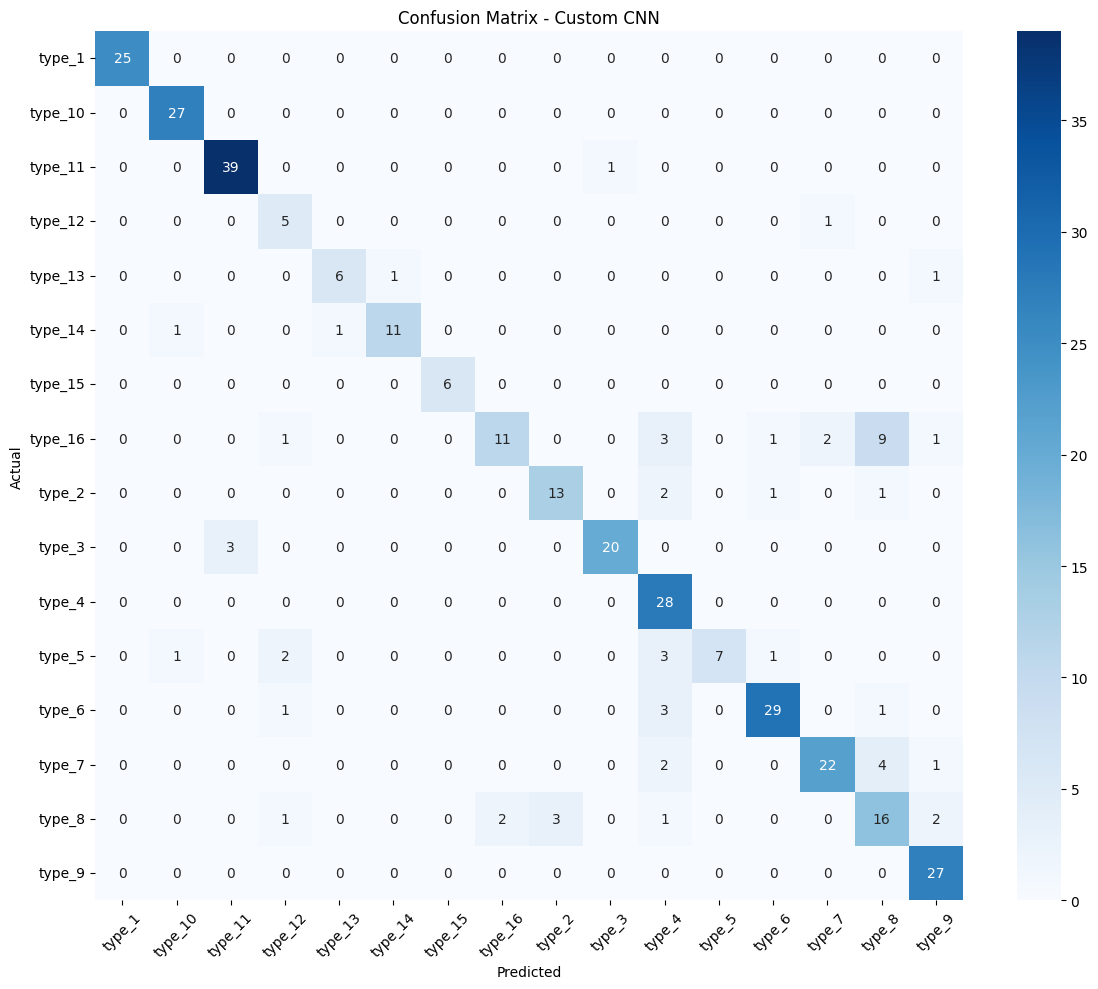

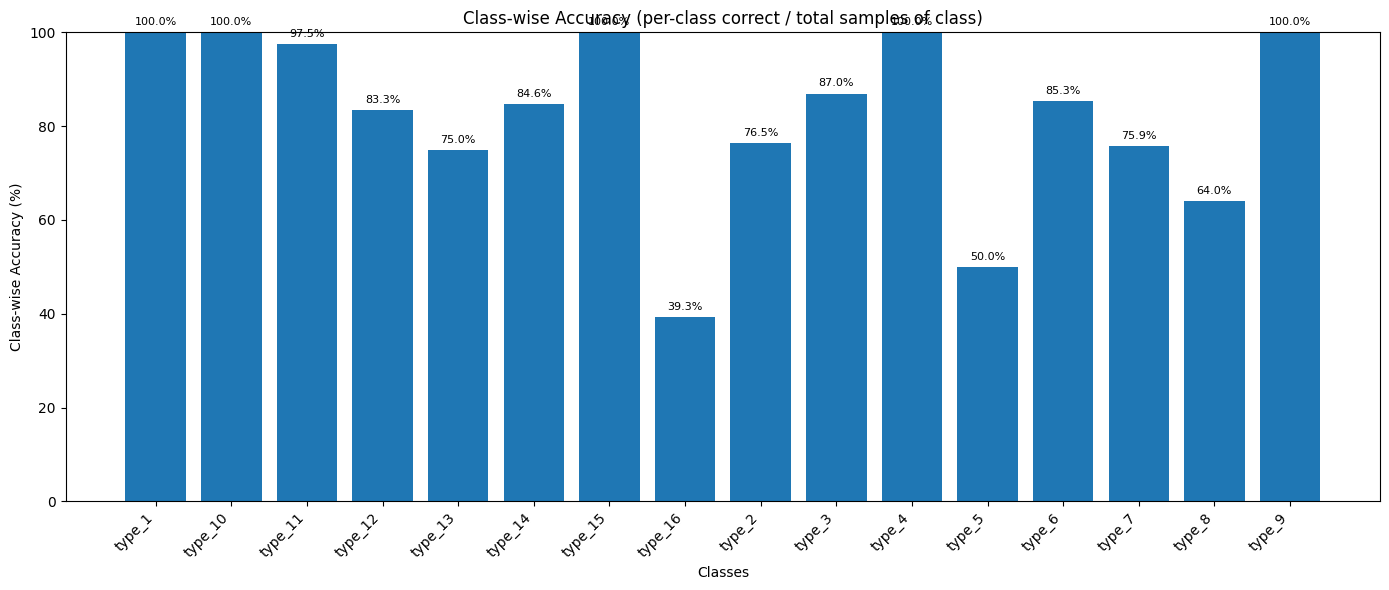

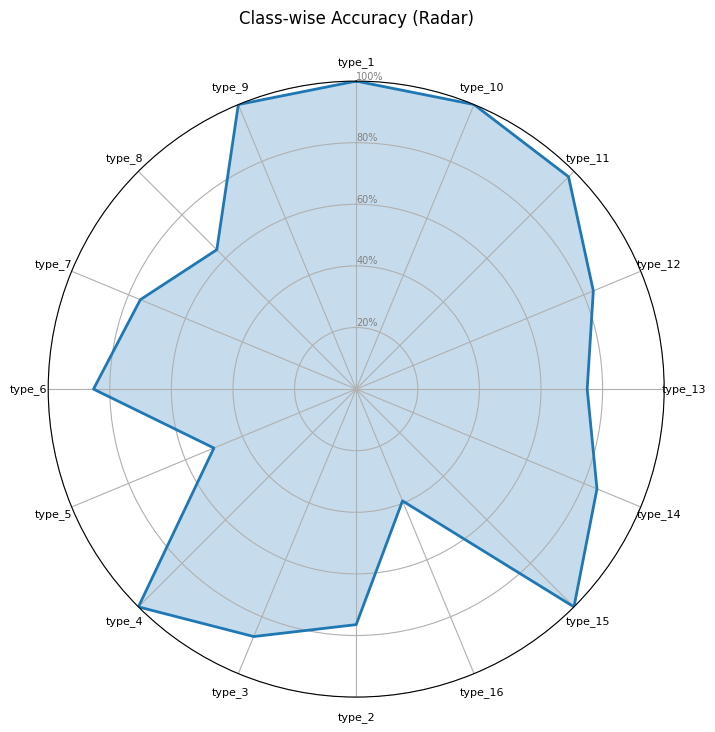

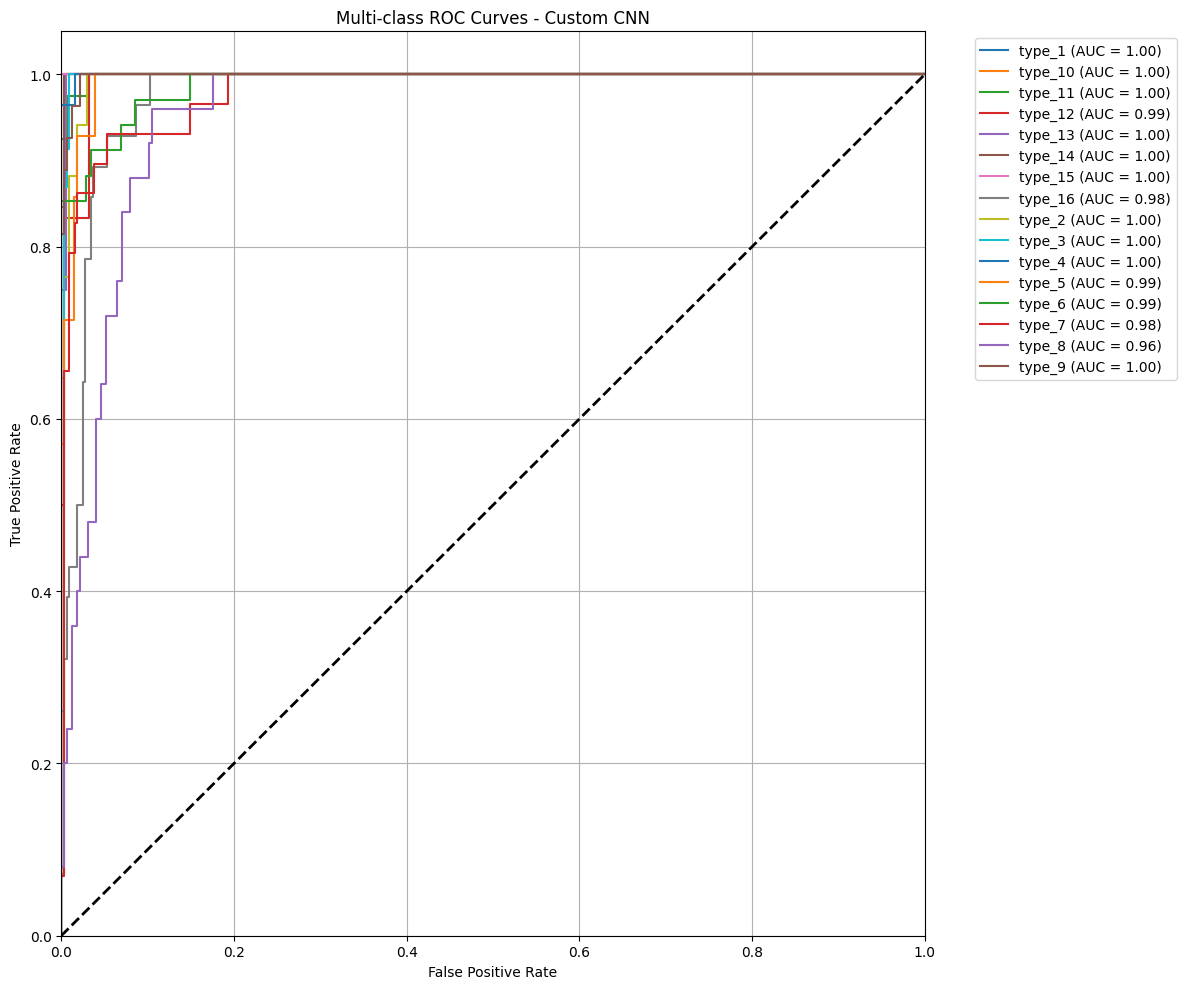

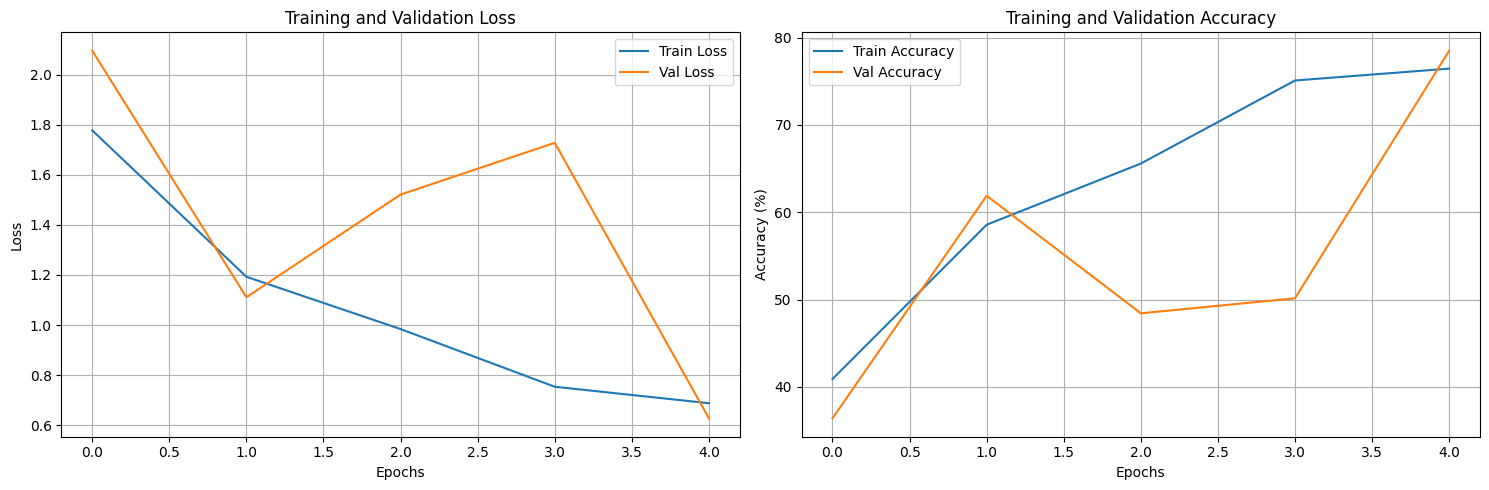


6. Statistical Comparison (Paired t-test)
Paired t-test between train and validation accuracies (n=5): t = 1.4906, p = 0.2103
Result: no statistically significant difference (p >= 0.05).

FINAL RESULTS SUMMARY - CUSTOM CNN MODEL
Training Time: 513.17 seconds
Inference Time: 6.73 seconds
Test Accuracy: 83.43%
Weighted Precision: 0.8547
Weighted Recall: 0.8343
Weighted F1-Score: 0.8293
Number of Parameters: 530,192

Class-wise metrics (first 10 rows):
     Class  Precision    Recall  F1-Score  Support  Class_Accuracy(%)
0   type_1   1.000000  1.000000  1.000000       25            100.000
1  type_10   0.931034  1.000000  0.964286       27            100.000
2  type_11   0.928571  0.975000  0.951220       40             97.500
3  type_12   0.500000  0.833333  0.625000        6             83.333
4  type_13   0.857143  0.750000  0.800000        8             75.000
5  type_14   0.916667  0.846154  0.880000       13             84.615
6  type_15   1.000000  1.000000  1.000000        6     

In [1]:
# -*- coding: utf-8 -*-
"""
Custom CNN Model for Rare and Endangered Medicinal Plants Classification
Task 3 of CSE366 Mini Project
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from scipy import stats
import time
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# =============================================================================
# Data Preparation with Augmentation
# =============================================================================
class DataPreprocessor:
    def __init__(self, data_path, img_size=128, batch_size=32):
        self.data_path = data_path
        self.img_size = img_size
        self.batch_size = batch_size
        
    def get_transforms(self):
        """Define training and validation transforms with augmentation"""
        train_transforms = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        val_transforms = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        return train_transforms, val_transforms
    
    def prepare_datasets(self):
        """Prepare datasets and dataloaders"""
        train_transforms, val_transforms = self.get_transforms()
        
        # Load full dataset
        full_dataset = datasets.ImageFolder(
            root=self.data_path,
            transform=train_transforms
        )
        
        # Get class names
        self.class_names = full_dataset.classes
        print(f"Dataset classes: {self.class_names}")
        print(f"Total samples: {len(full_dataset)}")
        
        # Split dataset (80% train, 10% validation, 10% test)
        train_size = int(0.8 * len(full_dataset))
        val_size = int(0.1 * len(full_dataset))
        test_size = len(full_dataset) - train_size - val_size
        
        train_dataset, val_test_dataset = random_split(
            full_dataset, [train_size, val_size + test_size]
        )
        
        val_dataset, test_dataset = random_split(
            val_test_dataset, [val_size, test_size]
        )
        
        # Apply validation transforms to val and test datasets
        val_dataset.dataset.transform = val_transforms
        test_dataset.dataset.transform = val_transforms
        
        print(f"Training samples: {len(train_dataset)}")
        print(f"Validation samples: {len(val_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        return train_dataset, val_dataset, test_dataset
    
    def prepare_dataloaders(self):
        """Prepare dataloaders"""
        train_dataset, val_dataset, test_dataset = self.prepare_datasets()
        
        train_loader = DataLoader(
            train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )
        
        val_loader = DataLoader(
            val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )
        
        test_loader = DataLoader(
            test_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )
        
        return train_loader, val_loader, test_loader

# =============================================================================
# Custom CNN Model Definition
# =============================================================================
class CustomPlantCNN(nn.Module):
    def __init__(self, num_classes=16, dropout_rate=0.5):
        super(CustomPlantCNN, self).__init__()
        
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Convolutional Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Convolutional Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Convolutional Block 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(256, 512)
        self.bn5 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, num_classes)
        
        # Regularization
        self.dropout = nn.Dropout(dropout_rate)
        self.pool = nn.MaxPool2d(2, 2)
        
    def forward(self, x):
        # Block 1: Conv -> BN -> ReLU -> Pool
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        
        # Block 2: Conv -> BN -> ReLU -> Pool
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        
        # Block 3: Conv -> BN -> ReLU -> Pool
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        
        # Block 4: Conv -> BN -> ReLU -> Pool
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        
        # Global Average Pooling
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = torch.relu(self.bn5(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# =============================================================================
# Model Training with Early Stopping
# =============================================================================
class PlantTrainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device, scheduler=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
    def train_epoch(self):
        """Train for one epoch"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc='Training')
        for batch_idx, (data, targets) in enumerate(pbar):
            data, targets = data.to(self.device), targets.to(self.device)
            
            # Forward pass
            outputs = self.model(data)
            loss = self.criterion(outputs, targets)
            
            # Backward pass and optimize
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # Update progress bar
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
        
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def validate_epoch(self):
        """Validate for one epoch"""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, targets in self.val_loader:
                data, targets = data.to(self.device), targets.to(self.device)
                
                outputs = self.model(data)
                loss = self.criterion(outputs, targets)
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def train(self, epochs, patience=10):
        """Full training loop with early stopping"""
        best_val_acc = 0
        patience_counter = 0
        start_time = time.time()
        
        print("Starting training...")
        for epoch in range(epochs):
            print(f'\nEpoch {epoch+1}/{epochs}')
            print('-' * 50)
            
            # Train and validate
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate_epoch()
            
            # Store metrics
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            
            # Learning rate scheduling
            if self.scheduler:
                self.scheduler.step(val_acc)
            
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
            
            # Early stopping check
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_custom_cnn.pth')
                print(f'New best model saved! Validation Accuracy: {val_acc:.2f}%')
            else:
                patience_counter += 1
                print(f'Early stopping counter: {patience_counter}/{patience}')
                
            if patience_counter >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs!')
                break
        
        training_time = time.time() - start_time
        print(f'\nTraining completed in {training_time:.2f} seconds')
        print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
        
        return training_time

# =============================================================================
# Comprehensive Model Evaluation
# =============================================================================
class ModelEvaluator:
    def __init__(self, model, test_loader, device, class_names):
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.class_names = class_names
        
    def evaluate_model(self):
        """Comprehensive model evaluation"""
        self.model.eval()
        all_predictions = []
        all_targets = []
        all_probabilities = []
        test_correct = 0
        test_total = 0
        
        start_time = time.time()
        with torch.no_grad():
            for data, targets in tqdm(self.test_loader, desc='Testing'):
                data, targets = data.to(self.device), targets.to(self.device)
                
                outputs = self.model(data)
                probabilities = torch.softmax(outputs, dim=1)
                _, predicted = outputs.max(1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())
                
                test_total += targets.size(0)
                test_correct += predicted.eq(targets).sum().item()
        
        inference_time = time.time() - start_time
        
        # Calculate metrics
        accuracy = 100. * test_correct / test_total
        all_predictions = np.array(all_predictions)
        all_targets = np.array(all_targets)
        all_probabilities = np.array(all_probabilities)
        
        print(f'\nTest Accuracy: {accuracy:.2f}%')
        print(f'Inference Time: {inference_time:.2f} seconds')
        
        return all_predictions, all_targets, all_probabilities, accuracy, inference_time
    
    def calculate_detailed_metrics(self, predictions, targets):
        """Calculate precision, recall, F1-score for each class"""
        precision, recall, f1, support = precision_recall_fscore_support(
            targets, predictions, average=None, labels=range(len(self.class_names))
        )
        
        # Overall metrics
        overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
            targets, predictions, average='weighted'
        )
        
        metrics_df = pd.DataFrame({
            'Class': self.class_names,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'Support': support
        })
        
        print("\nDetailed Class-wise Metrics:")
        print(metrics_df)
        
        print(f"\nOverall Metrics:")
        print(f"Weighted Precision: {overall_precision:.4f}")
        print(f"Weighted Recall: {overall_recall:.4f}")
        print(f"Weighted F1-Score: {overall_f1:.4f}")
        
        return metrics_df, overall_precision, overall_recall, overall_f1
    
    def plot_confusion_matrix(self, predictions, targets):
        """Plot confusion matrix"""
        cm = confusion_matrix(targets, predictions)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.class_names,
                   yticklabels=self.class_names)
        plt.title('Confusion Matrix - Custom CNN')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        return cm
    
    def compute_class_accuracy(self, cm):
        """Compute class-wise accuracy from confusion matrix (correct / total per class)."""
        # Avoid division by zero
        with np.errstate(divide='ignore', invalid='ignore'):
            class_acc = np.diag(cm) / cm.sum(axis=1)
            class_acc = np.nan_to_num(class_acc)  # turn nan into 0
        return class_acc  # values between 0 and 1

    def plot_classwise_accuracy(self, predictions, targets):
        """Plot class-wise accuracy as bar chart and radar (spider) chart"""
        cm = confusion_matrix(targets, predictions)
        class_acc = self.compute_class_accuracy(cm)  # fractions
        
        # Bar chart (percentage)
        plt.figure(figsize=(14, 6))
        x = np.arange(len(self.class_names))
        acc_percent = class_acc * 100
        plt.bar(x, acc_percent)
        plt.xticks(x, self.class_names, rotation=45, ha='right')
        plt.ylabel('Class-wise Accuracy (%)')
        plt.xlabel('Classes')
        plt.title('Class-wise Accuracy (per-class correct / total samples of class)')
        plt.ylim(0, 100)
        for i, v in enumerate(acc_percent):
            plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=8)
        plt.tight_layout()
        plt.show()
        
        # Radar (spider) chart
        # Prepare data (close the loop)
        labels = self.class_names
        N = len(labels)
        values = class_acc.tolist()
        values += values[:1]
        angles = [n / float(N) * 2 * np.pi for n in range(N)]
        angles += angles[:1]
        
        plt.figure(figsize=(8, 8))
        ax = plt.subplot(111, polar=True)
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        plt.xticks(angles[:-1], labels, color='black', size=8)
        ax.set_rlabel_position(0)
        yticks = [0.2, 0.4, 0.6, 0.8, 1.0]
        ytick_labels = [f'{int(t*100)}%' for t in yticks]
        plt.yticks(yticks, ytick_labels, color="grey", size=7)
        plt.ylim(0, 1.0)
        
        ax.plot(angles, values, linewidth=2, linestyle='solid')
        ax.fill(angles, values, alpha=0.25)
        plt.title('Class-wise Accuracy (Radar)', y=1.08)
        plt.show()
        
        # Return raw numbers for saving
        class_acc_percent = (class_acc * 100).round(3)
        acc_df = pd.DataFrame({'Class': labels, 'Class_Accuracy(%)': class_acc_percent})
        return acc_df, cm

    def plot_roc_curves(self, targets, probabilities):
        """Plot ROC curves for each class"""
        # Binarize the output
        y_test_bin = label_binarize(targets, classes=range(len(self.class_names)))
        
        # Compute ROC curve and ROC area for each class
        fpr = {}
        tpr = {}
        roc_auc = {}
        
        plt.figure(figsize=(12, 10))
        for i in range(len(self.class_names)):
            try:
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probabilities[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
                plt.plot(fpr[i], tpr[i], 
                        label=f'{self.class_names[i]} (AUC = {roc_auc[i]:.2f})')
            except ValueError:
                # If a class has no positive samples in y_test_bin[:, i], skip plotting
                roc_auc[i] = np.nan
                continue
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multi-class ROC Curves - Custom CNN')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        return roc_auc
    
    def plot_training_history(self, trainer):
        """Plot training history"""
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(trainer.train_losses, label='Train Loss')
        plt.plot(trainer.val_losses, label='Val Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.plot(trainer.train_accuracies, label='Train Accuracy')
        plt.plot(trainer.val_accuracies, label='Val Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy (%)')
        plt.title('Training and Validation Accuracy')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

# =============================================================================
# Main Execution for Task 3
# =============================================================================
def run_custom_cnn():
    """Main function to run Custom CNN model"""
    print("=" * 60)
    print("TASK 3: Custom CNN Model Implementation")
    print("=" * 60)
    
    # Configuration
    DATA_PATH = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"
    IMG_SIZE = 128
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 5
    PATIENCE = 3  # Reduced from 10 to 3 for better early stopping with only 5 epochs
    
    # Step 1: Data Preparation
    print("\n1. Preparing Data...")
    preprocessor = DataPreprocessor(DATA_PATH, IMG_SIZE, BATCH_SIZE)
    train_loader, val_loader, test_loader = preprocessor.prepare_dataloaders()
    class_names = preprocessor.class_names
    
    # Step 2: Model Initialization
    print("\n2. Initializing Custom CNN Model...")
    model = CustomPlantCNN(num_classes=len(class_names), dropout_rate=0.5)
    model = model.to(device)
    
    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Step 3: Training Setup
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)  # Reduced patience for scheduler too
    
    # Step 4: Training
    print("\n3. Starting Training...")
    trainer = PlantTrainer(model, train_loader, val_loader, criterion, optimizer, device, scheduler)
    training_time = trainer.train(EPOCHS, PATIENCE)
    
    # Step 5: Load Best Model and Evaluate
    print("\n4. Loading Best Model and Evaluating...")
    model.load_state_dict(torch.load('best_custom_cnn.pth'))
    
    evaluator = ModelEvaluator(model, test_loader, device, class_names)
    predictions, targets, probabilities, test_accuracy, inference_time = evaluator.evaluate_model()
    
    # Step 6: Generate Comprehensive Reports
    print("\n5. Generating Evaluation Reports...")
    
    # Detailed metrics
    metrics_df, overall_precision, overall_recall, overall_f1 = evaluator.calculate_detailed_metrics(predictions, targets)
    
    # Confusion Matrix
    cm = evaluator.plot_confusion_matrix(predictions, targets)
    
    # Class-wise accuracy plots (bar + radar) and get class accuracy dataframe
    class_acc_df, cm_returned = evaluator.plot_classwise_accuracy(predictions, targets)
    # Merge class accuracy into metrics_df
    metrics_df = metrics_df.merge(class_acc_df, on='Class', how='left')
    
    # ROC Curves
    roc_auc = evaluator.plot_roc_curves(targets, probabilities)
    
    # Training History
    evaluator.plot_training_history(trainer)
    
    # Step: Paired t-test (training vs validation accuracies across epochs)
    # If the lengths differ (shouldn't), take min length
    print("\n6. Statistical Comparison (Paired t-test)")
    train_accs = np.array(trainer.train_accuracies)
    val_accs = np.array(trainer.val_accuracies)
    min_len = min(len(train_accs), len(val_accs))
    if min_len == 0:
        print("Not enough epoch data to perform paired t-test (need at least 1 epoch).")
        t_stat, p_val = np.nan, np.nan
    else:
        train_slice = train_accs[:min_len]
        val_slice = val_accs[:min_len]
        t_stat, p_val = stats.ttest_rel(train_slice, val_slice)
        print(f"Paired t-test between train and validation accuracies (n={min_len}): t = {t_stat:.4f}, p = {p_val:.4f}")
        alpha = 0.05
        if np.isnan(p_val):
            print("Paired t-test result is not available (NaN).")
        elif p_val < alpha:
            print(f"Result: statistically significant difference (p < {alpha}).")
        else:
            print(f"Result: no statistically significant difference (p >= {alpha}).")
    
    # Step 7: Final Summary
    print("\n" + "=" * 60)
    print("FINAL RESULTS SUMMARY - CUSTOM CNN MODEL")
    print("=" * 60)
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Weighted Precision: {overall_precision:.4f}")
    print(f"Weighted Recall: {overall_recall:.4f}")
    print(f"Weighted F1-Score: {overall_f1:.4f}")
    print(f"Number of Parameters: {total_params:,}")
    print("\nClass-wise metrics (first 10 rows):")
    print(metrics_df.head(10))
    
    # Save results
    results_df = pd.DataFrame({
        'Model': ['Custom CNN'],
        'Training_Time': [training_time],
        'Inference_Time': [inference_time],
        'Test_Accuracy': [test_accuracy],
        'Precision': [overall_precision],
        'Recall': [overall_recall],
        'F1_Score': [overall_f1],
        'Parameters': [total_params]
    })
    
    results_df.to_csv('custom_cnn_results.csv', index=False)
    metrics_df.to_csv('custom_cnn_class_metrics.csv', index=False)
    class_acc_df.to_csv('custom_cnn_class_accuracy.csv', index=False)
    # save confusion matrix as csv
    pd.DataFrame(cm_returned, index=class_names, columns=class_names).to_csv('custom_cnn_confusion_matrix.csv')
    
    # Save ROC AUC per class
    roc_df = pd.DataFrame({
        'Class': list(roc_auc.keys()),
        'AUC': list(roc_auc.values())
    })
    roc_df['Class'] = roc_df['Class'].apply(lambda x: class_names[int(x)] if not pd.isna(x) else x)
    roc_df.to_csv('custom_cnn_roc_auc_per_class.csv', index=False)
    
    print("\nResults saved to CSV files: custom_cnn_results.csv, custom_cnn_class_metrics.csv, custom_cnn_class_accuracy.csv, custom_cnn_confusion_matrix.csv, custom_cnn_roc_auc_per_class.csv")
    
    return results_df, metrics_df

# Run the custom CNN model
if __name__ == "__main__":
    custom_cnn_results, custom_cnn_metrics = run_custom_cnn()
